# Task : 
- Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

 

# Customer Intelligence & Country Segmentation
## Unsupervised Learning for Strategic Insights

This notebook demonstrates a comprehensive clustering workflow designed to segment countries based on socio-economic and health metrics using Kaggle's Country Data dataset. 

### Project Objectives
- **Data Preparation:** Ingest, clean, and inspect raw data to ensure structural integrity.
- **Feature Engineering:** Preprocess and scale numerical features for optimal distance-based modeling.
- **Algorithmic Implementation:** Determine the optimal number of clusters using K-Means and evaluate DBSCAN as a density-based alternative.
- **Dimensionality Reduction:** Visualize complex, multi-dimensional clusters in a 2D space utilizing Principal Component Analysis (PCA).
- **Business Intelligence:** Translate model outputs into actionable, real-world socio-economic insights.

## 1) Install required libraries

In [1]:
!pip -q install  numpy  seaborn scikit-learn pandas matplotlib

## 2) Import libraries

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## 3) Load the dataset

In [16]:
df = pd.read_csv('Country-data.csv')

dictionary_df = pd.read_csv('data-dictionary.csv')


In [13]:
dictionary_df


,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [19]:
print("Shape of the country dataset:", df.shape)
df.info()
display(df.describe(include='all').T)
df.head()


Shape of the country dataset: (167, 10)
<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Data cleaning

In [20]:
# 1. Standardize column names
df.columns = [col.strip().lower() for col in df.columns]
 
# 2. Handle Missing Values (Imputation)
# Isolate just the columns with numbers means 
numeric_cols = [c for c in df.columns if c != 'country']

# Fill any blank spaces with the 'median' (middle value) of that specific column
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 5. Verify the cleaning worked (This should output 0 missing values for every column)
print(df.isna().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## 5) Exploratory Data Analysis

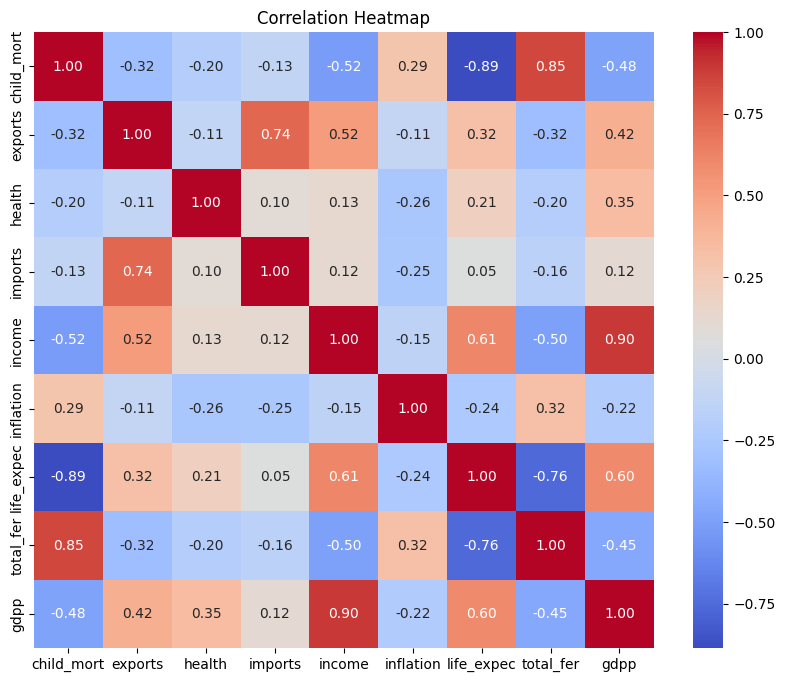

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

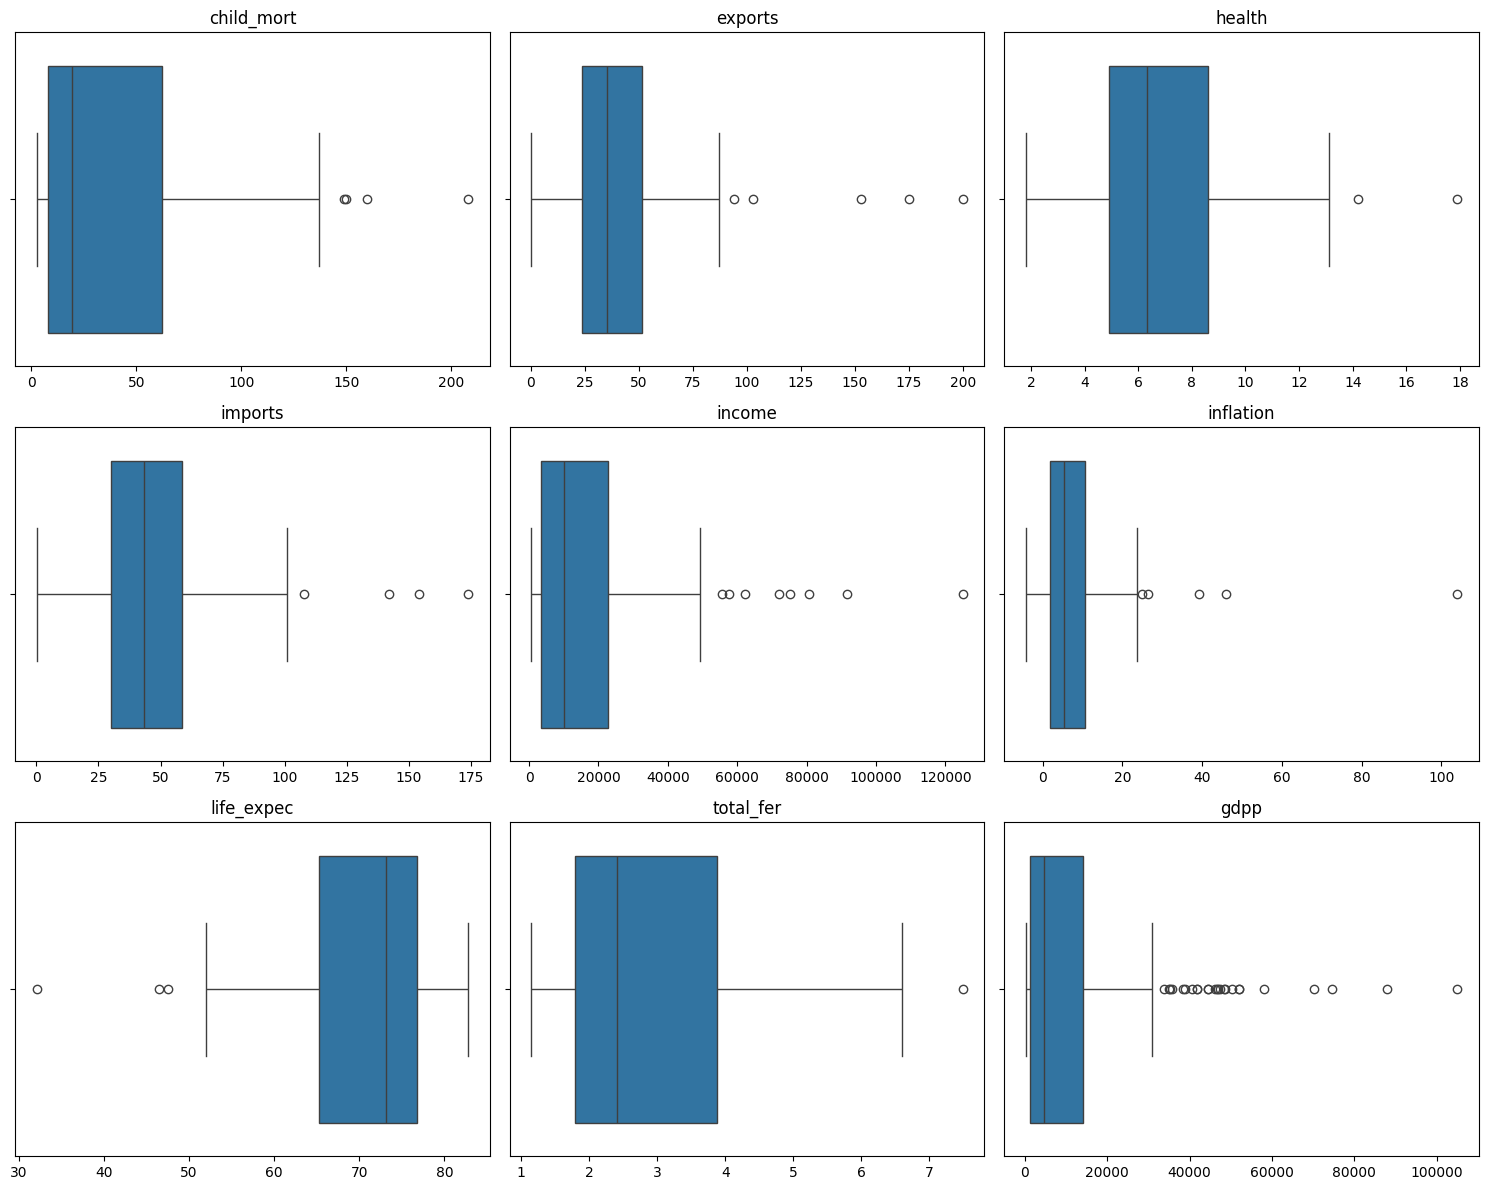

In [27]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])  
    axes[i].set_title(f'{col}')                 # Set the title for that box
    axes[i].set_xlabel('')                      # Remove x-label to keep it clean

plt.tight_layout()
plt.show()

## 6) Feature scaling

In [31]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

x_scaled_df = pd.DataFrame(X_scaled, columns=features.columns)
x_scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## 7) K-Means: Elbow method

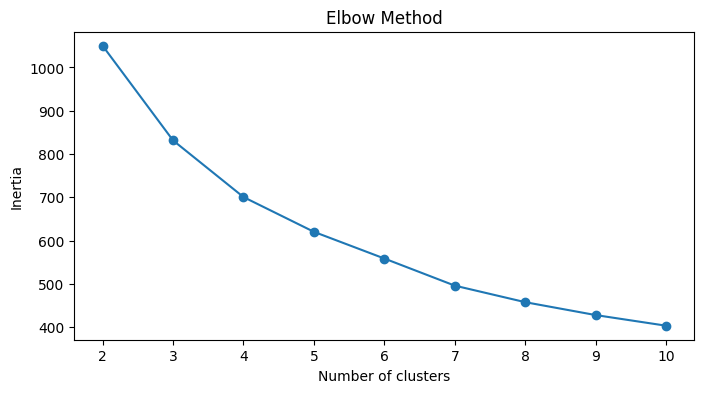

In [32]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

## ) Try PCA visualization for diff val of k

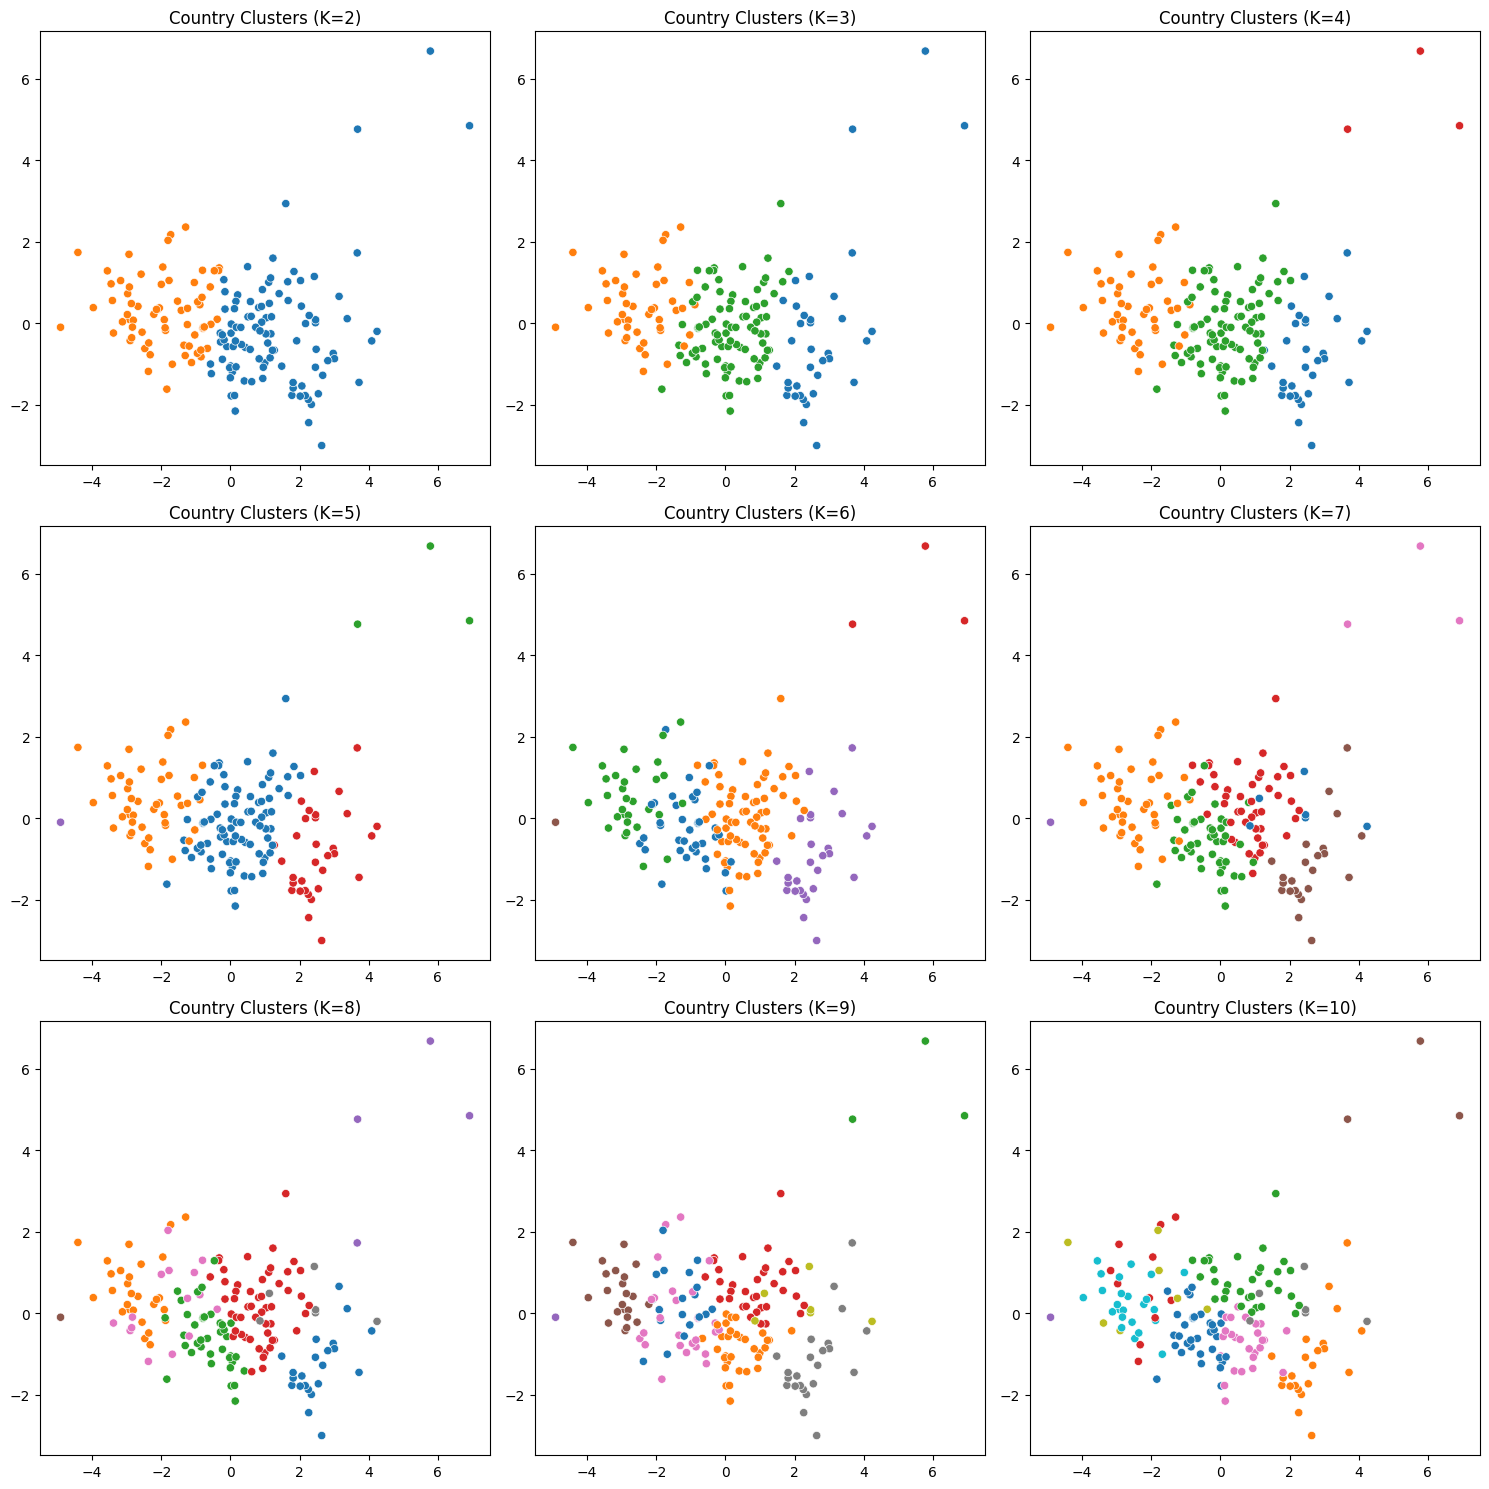

In [36]:
from sklearn.decomposition import PCA

# 1. Compress the 9-dimensional scaled data down to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a temporary DataFrame just for the visualization
viz_df = pd.DataFrame(data=X_pca, columns=['PCA_Component_1', 'PCA_Component_2'])

# 2. Set up a 3x3 grid for our 9 plots (K=2 through 10)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten() # Flatten to a 1D list for easy looping

# 3. Loop through K=2 to 10
k_values = range(2, 11)

for i, k in enumerate(k_values):
    # Train the model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Predict clusters
    viz_df['Cluster'] = kmeans.fit_predict(X_scaled) 
    
    # Draw the scatter plot
    sns.scatterplot(
        data=viz_df, 
        x='PCA_Component_1', 
        y='PCA_Component_2', 
        hue='Cluster', 
        palette='tab10', 
        ax=axes[i],
        legend=False # We turn off the legend here so the boxes don't get cluttered
    )
    axes[i].set_title(f'Country Clusters (K={k})')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# 4. Adjust spacing and display
plt.tight_layout()
plt.show()

## 18) Train K-Means

In [39]:
best_k = 3  # change after checking the elbow plot
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

Silhouette Score: 0.28329575683463126


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## 9)  DBSCAN

In [43]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


## 10)Cluster profiling

In [46]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45



## ) Write 3 to 5 observations about the clusters:
- Which cluster has high child mortality?
- Which cluster has high income and gdpp?
- Which cluster looks underdeveloped?
- Which countries should be prioritized for aid?


In [50]:
# cluster  has high child moritality

child_mortality_cluster = profile['child_mort']# Cluster with highest child mortality
high_child_mort_cluster = profile['child_mort'].idxmax()
print("Cluster with highest child mortality:", high_child_mort_cluster)

Cluster with highest child mortality: 1


In [51]:
# Cluster with highest income
high_income_cluster = profile['income'].idxmax()
print("Cluster with highest income:", high_income_cluster)

# Cluster with highest GDPP
high_gdpp_cluster = profile['gdpp'].idxmax()
print("Cluster with highest GDPP:", high_gdpp_cluster)

Cluster with highest income: 0
Cluster with highest GDPP: 0


In [52]:
# Cluster with highest income
high_income_cluster = profile['income'].idxmax()
print("Cluster with highest income:", high_income_cluster)

# Cluster with highest GDPP
high_gdpp_cluster = profile['gdpp'].idxmax()
print("Cluster with highest GDPP:", high_gdpp_cluster)

Cluster with highest income: 0
Cluster with highest GDPP: 0


In [53]:
# Underdeveloped cluster
underdeveloped_cluster = profile['gdpp'].idxmin()
print("Most underdeveloped cluster:", underdeveloped_cluster)

Most underdeveloped cluster: 1


In [54]:
# Countries that should be prioritized for aid
priority_countries = df[df['kmeans_cluster'] == underdeveloped_cluster]['country']

print("Countries to prioritize for aid:")
print(priority_countries.tolist())

Countries to prioritize for aid:
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Haiti', 'Iraq', 'Kenya', 'Kiribati', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Sierra Leone', 'South Africa', 'Sudan', 'Tanzania', 'Timor-Leste', 'Togo', 'Uganda', 'Yemen', 'Zambia']


In [55]:
# find cluster of india
india_cluster = df[df['country'] == 'India']['kmeans_cluster'].values[0]
print("India belongs to cluster:", india_cluster)

India belongs to cluster: 2


### PCA for Cluster Profile

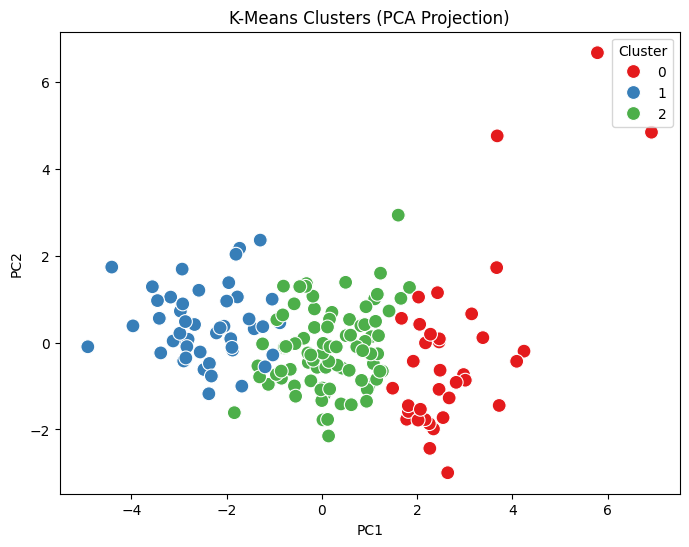

In [60]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_data, columns=['PC1','PC2'])
pca_df['Cluster'] = df['kmeans_cluster']

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title('K-Means Clusters (PCA Projection)')
plt.show()

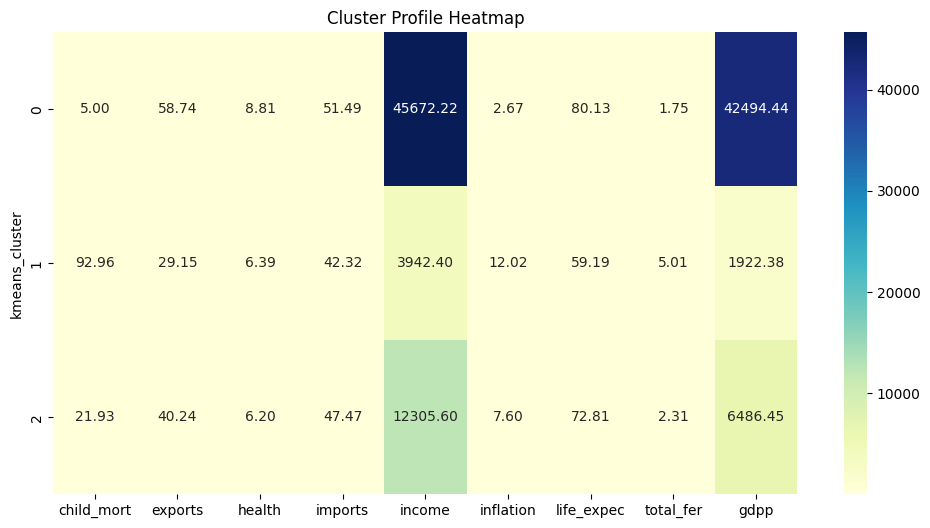

In [56]:
 
plt.figure(figsize=(12,6))
sns.heatmap(profile, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Cluster Profile Heatmap')
plt.show()

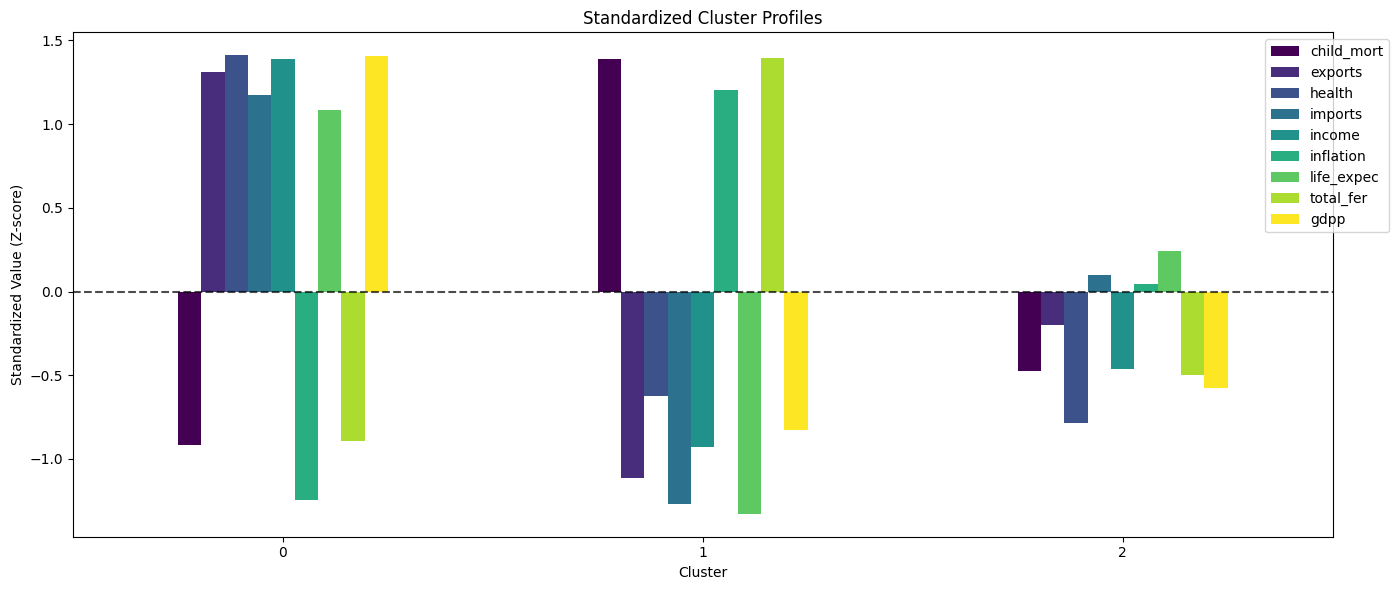

In [61]:
# Standardize the cluster profile
scaler = StandardScaler()

profile_scaled = pd.DataFrame(
    scaler.fit_transform(profile),
    columns=profile.columns,
    index=profile.index
)

# Plot standardized profile
profile_scaled.plot(
    kind='bar',
    figsize=(14,6),
    colormap='viridis'
)

plt.title('Standardized Cluster Profiles')
plt.ylabel('Standardized Value (Z-score)')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## 11) Conclusion

Cluster 1 is identified as the most vulnerable group, exhibiting the highest child mortality (92.96), lowest income (3942.40), lowest GDPP (1922.38), lowest life expectancy (59.19 years), and highest fertility rate (5.01). These characteristics indicate significant socio-economic challenges, making Cluster 1 the primary target for international aid and development initiatives. In contrast, Cluster 0 represents highly developed nations with strong economic and health indicators, while Cluster 2 consists of moderately developed countries with intermediate characteristics.